# Supplementary Figure S6: Stage1 Latent Clustering

- Figure / panels: `FigS6a`, `FigS6b`, `FigS6c`, `FigS6d`
- Inputs: `artifacts/stage1_latent_clustering/pbmc_celltype/pbmc/split1/train_all_cells_seed24/*`
- Fallback: if the PBMC artifact is missing, rerun `run_stage1_latent_clustering(...)` with the same config
- Outputs: `artifacts/paper_figures/supp/FigS6_Stage1LatentClustering/*`
- Run order: supplementary-only; does not affect the main benchmark notebooks
- Role: PBMC split1 exemplar showing that Stage1 can learn biologically meaningful cell representations under this configuration


In [1]:
from __future__ import annotations

import json
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'scripts').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / 'src') not in sys.path:
    sys.path.insert(0, str(repo_root / 'src'))

from scripts.common.paper_plot_style import apply_gears_paper_style, style_axis
from scripts.trishift.analysis.stage1_latent_clustering import run_stage1_latent_clustering

apply_gears_paper_style(font_scale=1.0)


In [2]:
MODE = 'pbmc_celltype'  # fixed for the paper supplement
DATASET_NAME = 'pbmc'
SPLIT_ID = 1
STAGE1_POOL_MODE = 'train_all_cells'
RANDOM_SEED = 24

SOURCE_ROOT = repo_root / 'artifacts' / 'stage1_latent_clustering' / MODE / DATASET_NAME / f'split{SPLIT_ID}' / f'{STAGE1_POOL_MODE}_seed{RANDOM_SEED}'
OUT_ROOT = repo_root / 'artifacts' / 'paper_figures' / 'supp' / 'FigS6_Stage1LatentClustering'
OUT_ROOT.mkdir(parents=True, exist_ok=True)
print('Preferred source:', SOURCE_ROOT)
print('Output root:', OUT_ROOT)


Preferred source: E:\CODE\trishift\artifacts\stage1_latent_clustering\pbmc_celltype\pbmc\split1\train_all_cells_seed24
Output root: E:\CODE\trishift\artifacts\paper_figures\supp\FigS6_Stage1LatentClustering


In [3]:
if SOURCE_ROOT.exists() and (SOURCE_ROOT / 'cluster_metrics.csv').exists():
    source_dir = SOURCE_ROOT
else:
    result = run_stage1_latent_clustering(
        mode=MODE,
        dataset_name=DATASET_NAME,
        split_id=SPLIT_ID,
        stage1_pool_mode=STAGE1_POOL_MODE,
        random_seed=RANDOM_SEED,
    )
    source_dir = Path(result.out_dir)

metrics_df = pd.read_csv(source_dir / 'cluster_metrics.csv')
run_meta = json.loads((source_dir / 'run_meta.json').read_text(encoding='utf-8'))
metrics_df.to_csv(OUT_ROOT / 'figs6_cluster_metrics.csv', index=False, encoding='utf-8-sig')
(OUT_ROOT / 'figs6_source_run_meta.json').write_text(json.dumps(run_meta, indent=2, ensure_ascii=False), encoding='utf-8')
print('Resolved source:', source_dir)
display(metrics_df)


Resolved source: E:\CODE\trishift\artifacts\stage1_latent_clustering\pbmc_celltype\pbmc\split1\train_all_cells_seed24


,label_key,n_obs,n_unique_labels,n_unique_clusters,ari_leiden_vs_label,nmi_leiden_vs_label,silhouette_label,ARI_cluster/label,NMI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,graph_conn,avg_bio,avg_bio_source
0,label_cell_type,11990,9,11,0.629966,0.713677,0.022112,0.833326,0.785864,0.511056,0.987598,0.0,0.95567,0.710082,scib
1,label_condition,11990,2,11,0.000522,0.000620,0.000935,0.000522,0.000620,0.000935,NaN,NaN,NaN,0.000692,local


In [4]:
latent_h5ad_path = source_dir / 'latent_with_clusters.h5ad'
latent_adata = sc.read_h5ad(latent_h5ad_path) if latent_h5ad_path.exists() else None

# Re-render figure panels instead of copying old source PNGs so layout can be tuned here.
if latent_adata is not None:
    apply_gears_paper_style(font_scale=1.0)

    def _cluster_sort_key(value: str):
        text = str(value)
        return (0, int(text)) if text.isdigit() else (1, text)

    # FigS6a: UMAP by cluster
    cluster_levels = sorted(pd.Categorical(latent_adata.obs['leiden']).categories.tolist(), key=_cluster_sort_key)
    latent_adata.obs['leiden'] = pd.Categorical(latent_adata.obs['leiden'].astype(str), categories=cluster_levels, ordered=True)
    cluster_palette = sns.color_palette('tab20', n_colors=max(len(cluster_levels), 3)).as_hex()[:len(cluster_levels)]
    fig = sc.pl.umap(
        latent_adata,
        color=['leiden'],
        title=[''],
        frameon=False,
        return_fig=True,
        show=False,
        legend_loc='right margin',
        legend_fontsize=10,
        legend_fontoutline=0,
        palette=cluster_palette,
        size=14,
    )
    fig.set_size_inches(9.2, 6.8)
    fig.suptitle('PBMC split1 stage1 latent by cluster', y=0.98, fontsize=16, fontweight='semibold')
    for ax in fig.axes:
        if hasattr(ax, 'set_title'):
            ax.set_title('')
        style_axis(ax)
    fig.subplots_adjust(top=0.88, right=0.83)
    fig.savefig(OUT_ROOT / 'figs6a_umap_by_cluster.png', dpi=320, bbox_inches='tight')
    plt.close(fig)

    # FigS6b: UMAP by cell type
    cell_types = sorted(latent_adata.obs['label_cell_type'].astype(str).unique().tolist())
    palette_ct = sns.color_palette('tab10', n_colors=max(len(cell_types), 3)).as_hex()[:len(cell_types)]
    fig = sc.pl.umap(
        latent_adata,
        color=['label_cell_type'],
        title=[''],
        frameon=False,
        return_fig=True,
        show=False,
        legend_loc='right margin',
        legend_fontsize=8.5,
        legend_fontoutline=0,
        palette=palette_ct,
        size=14,
    )
    fig.set_size_inches(10.4, 7.0)
    fig.suptitle('Stage1 latent by cell type', y=0.98, fontsize=16, fontweight='semibold')
    for ax in fig.axes:
        if hasattr(ax, 'set_title'):
            ax.set_title('')
        style_axis(ax)
    fig.subplots_adjust(top=0.88, right=0.80)
    fig.savefig(OUT_ROOT / 'figs6b_umap_by_cell_type.png', dpi=320, bbox_inches='tight')
    plt.close(fig)

    # FigS6c: cluster vs cell type heatmap
    table = pd.crosstab(latent_adata.obs['label_cell_type'].astype(str), latent_adata.obs['leiden'].astype(str))
    table = table.reindex(columns=[str(x) for x in cluster_levels], fill_value=0)
    fig_w = max(8.0, 0.48 * table.shape[1] + 4.0)
    fig_h = max(5.4, 0.5 * table.shape[0] + 2.8)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=220)
    sns.heatmap(
        table.astype(float),
        cmap='Blues',
        annot=table.astype(int),
        fmt='d',
        linewidths=0.45,
        linecolor='white',
        cbar=True,
        cbar_kws={'shrink': 0.78, 'pad': 0.02},
        ax=ax,
    )
    ax.set_xlabel('Leiden cluster')
    ax.set_ylabel('Cell type')
    ax.set_title('Cluster vs cell type', fontsize=15, fontweight='semibold', pad=10)
    ax.tick_params(axis='x', rotation=35, labelsize=10)
    ax.tick_params(axis='y', rotation=0, labelsize=10)
    ax.grid(False)
    fig.tight_layout()
    fig.savefig(OUT_ROOT / 'figs6c_cluster_vs_cell_type.png', bbox_inches='tight')
    plt.close(fig)
else:
    figure_sources = {
        'figs6a_umap_by_cluster.png': source_dir / 'umap_by_cluster.png',
        'figs6b_umap_by_cell_type.png': source_dir / 'umap_by_label_cell_type.png',
        'figs6c_cluster_vs_cell_type.png': source_dir / 'cluster_vs_label_cell_type.png',
    }
    for out_name, src_path in figure_sources.items():
        if src_path.exists():
            shutil.copy2(src_path, OUT_ROOT / out_name)

metric_row = metrics_df[metrics_df['label_key'].astype(str) == 'label_cell_type'].copy()
metric_cols = [col for col in ['ARI_cluster/label', 'NMI_cluster/label', 'ASW_label', 'avg_bio'] if col in metric_row.columns]
plot_df = metric_row[metric_cols].melt(var_name='metric', value_name='value') if not metric_row.empty and metric_cols else pd.DataFrame(columns=['metric', 'value'])
fig, ax = plt.subplots(figsize=(6.8, 4.2), dpi=220)
if plot_df.empty:
    ax.text(0.5, 0.5, 'No PBMC cell-type metric summary available', ha='center', va='center')
    ax.axis('off')
else:
    plot_df['metric_label'] = plot_df['metric'].map({
        'ARI_cluster/label': 'ARI',
        'NMI_cluster/label': 'NMI',
        'ASW_label': 'ASW',
        'avg_bio': 'Avg. bio',
    }).fillna(plot_df['metric'])
    sns.barplot(data=plot_df, x='metric_label', y='value', color='#4C78A8', ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.set_title('PBMC clustering metrics', fontsize=15, fontweight='semibold', pad=10)
    style_axis(ax, grid_axis='y')
    ax.set_ylim(0, max(0.9, float(plot_df['value'].max()) + 0.08))
    for patch in ax.patches:
        patch.set_edgecolor('black')
        patch.set_linewidth(0.5)
        h = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2, h + 0.015, f'{h:.2f}', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
fig.savefig(OUT_ROOT / 'figs6d_cluster_metrics.png', bbox_inches='tight')
plt.close(fig)
plot_df.to_csv(OUT_ROOT / 'figs6d_cluster_metrics_values.csv', index=False, encoding='utf-8-sig')


E:\CODE\trishift\artifacts\paper_figures\supp\FigS6_Stage1LatentClustering\figs6a_umap_by_cluster.png


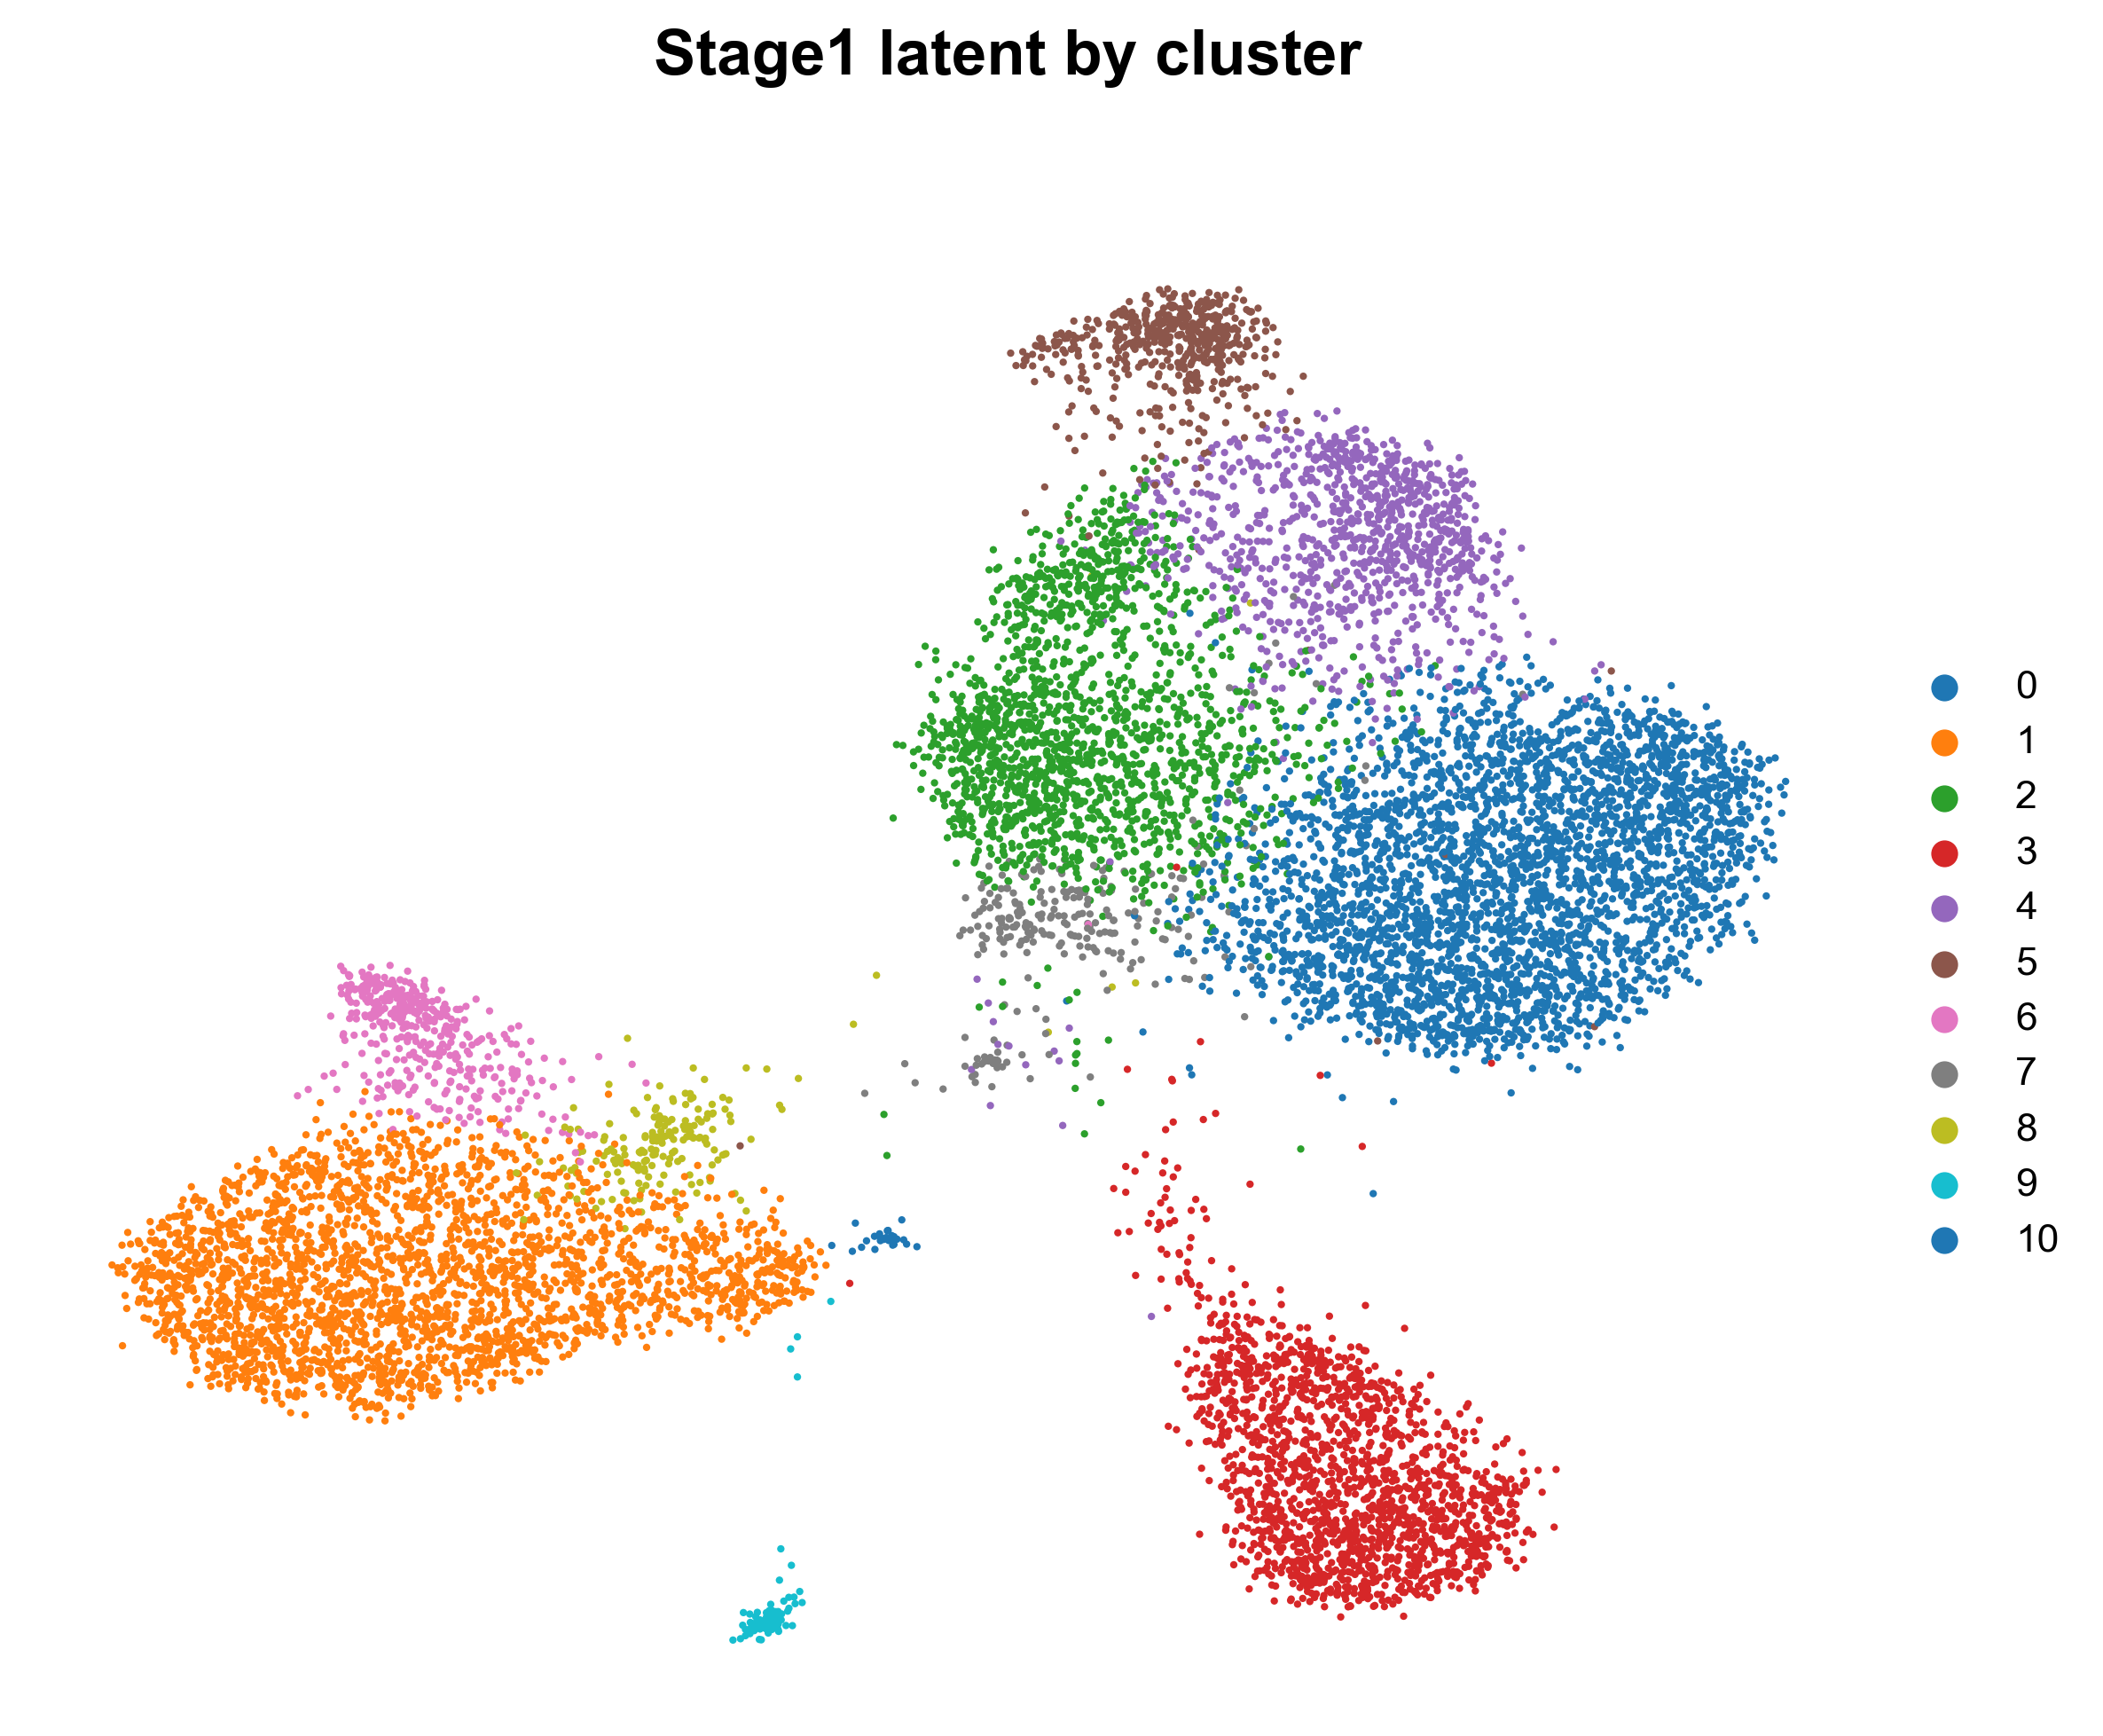

E:\CODE\trishift\artifacts\paper_figures\supp\FigS6_Stage1LatentClustering\figs6b_umap_by_cell_type.png


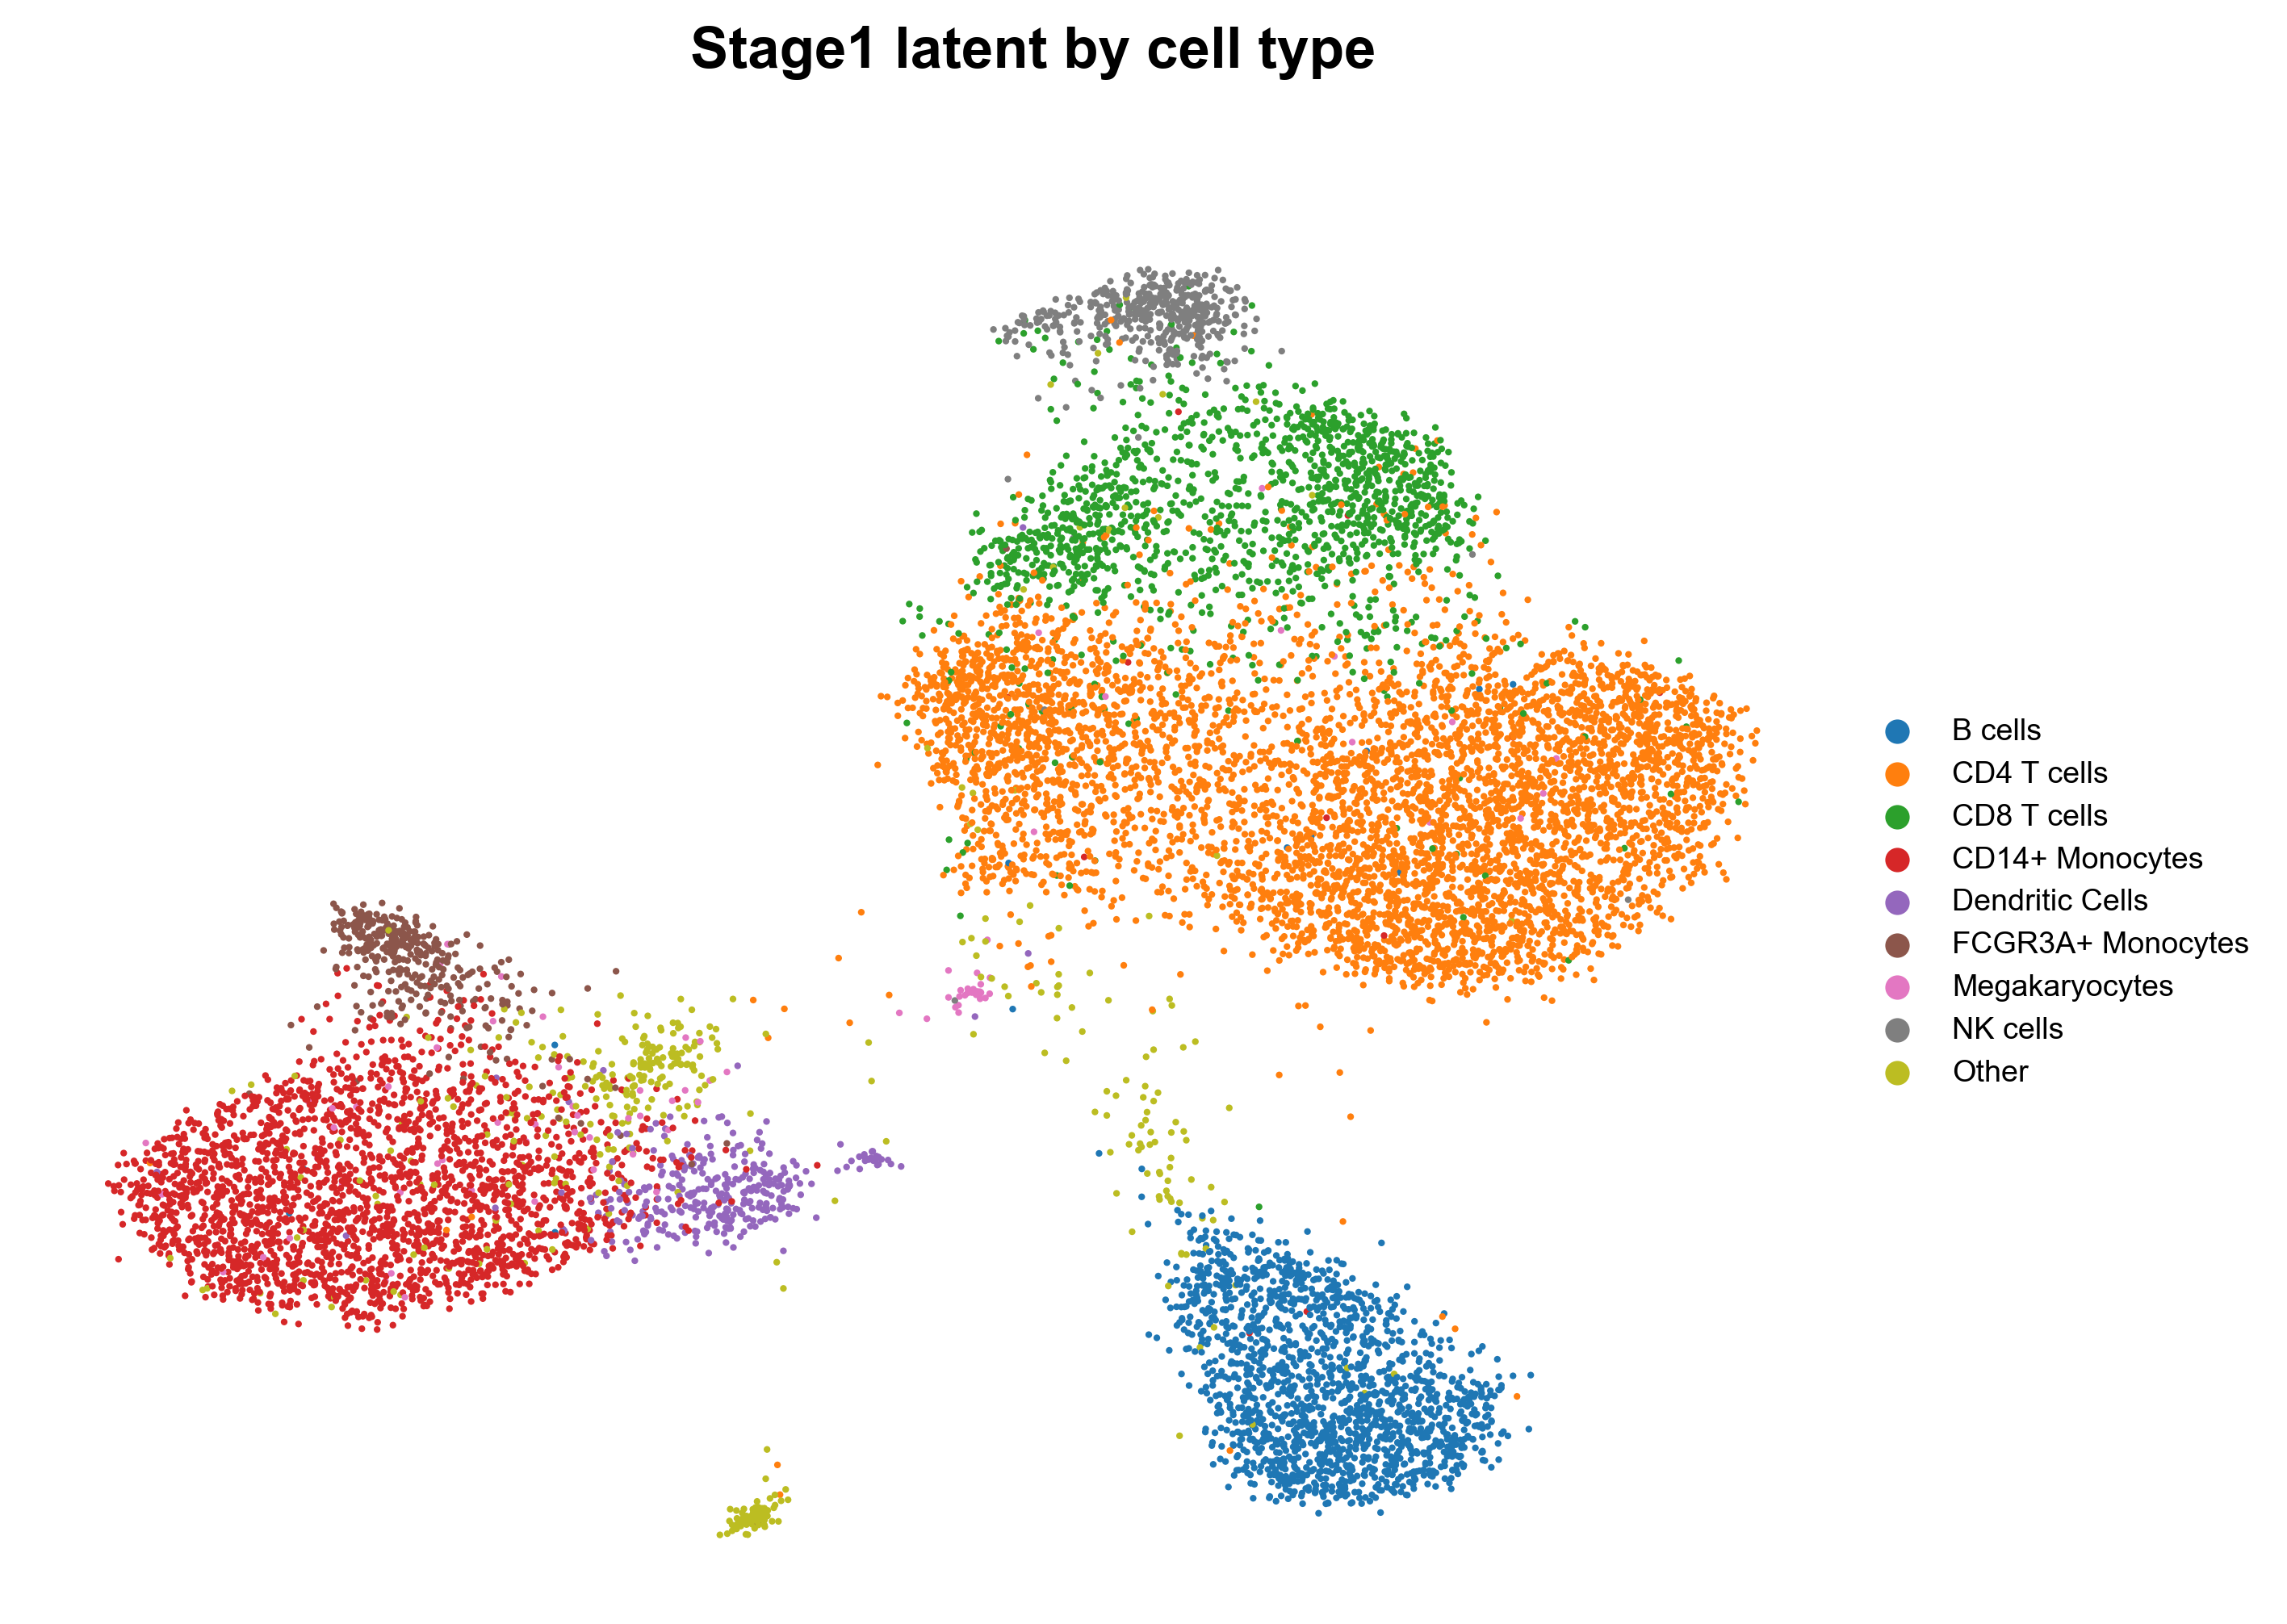

E:\CODE\trishift\artifacts\paper_figures\supp\FigS6_Stage1LatentClustering\figs6c_cluster_vs_cell_type.png


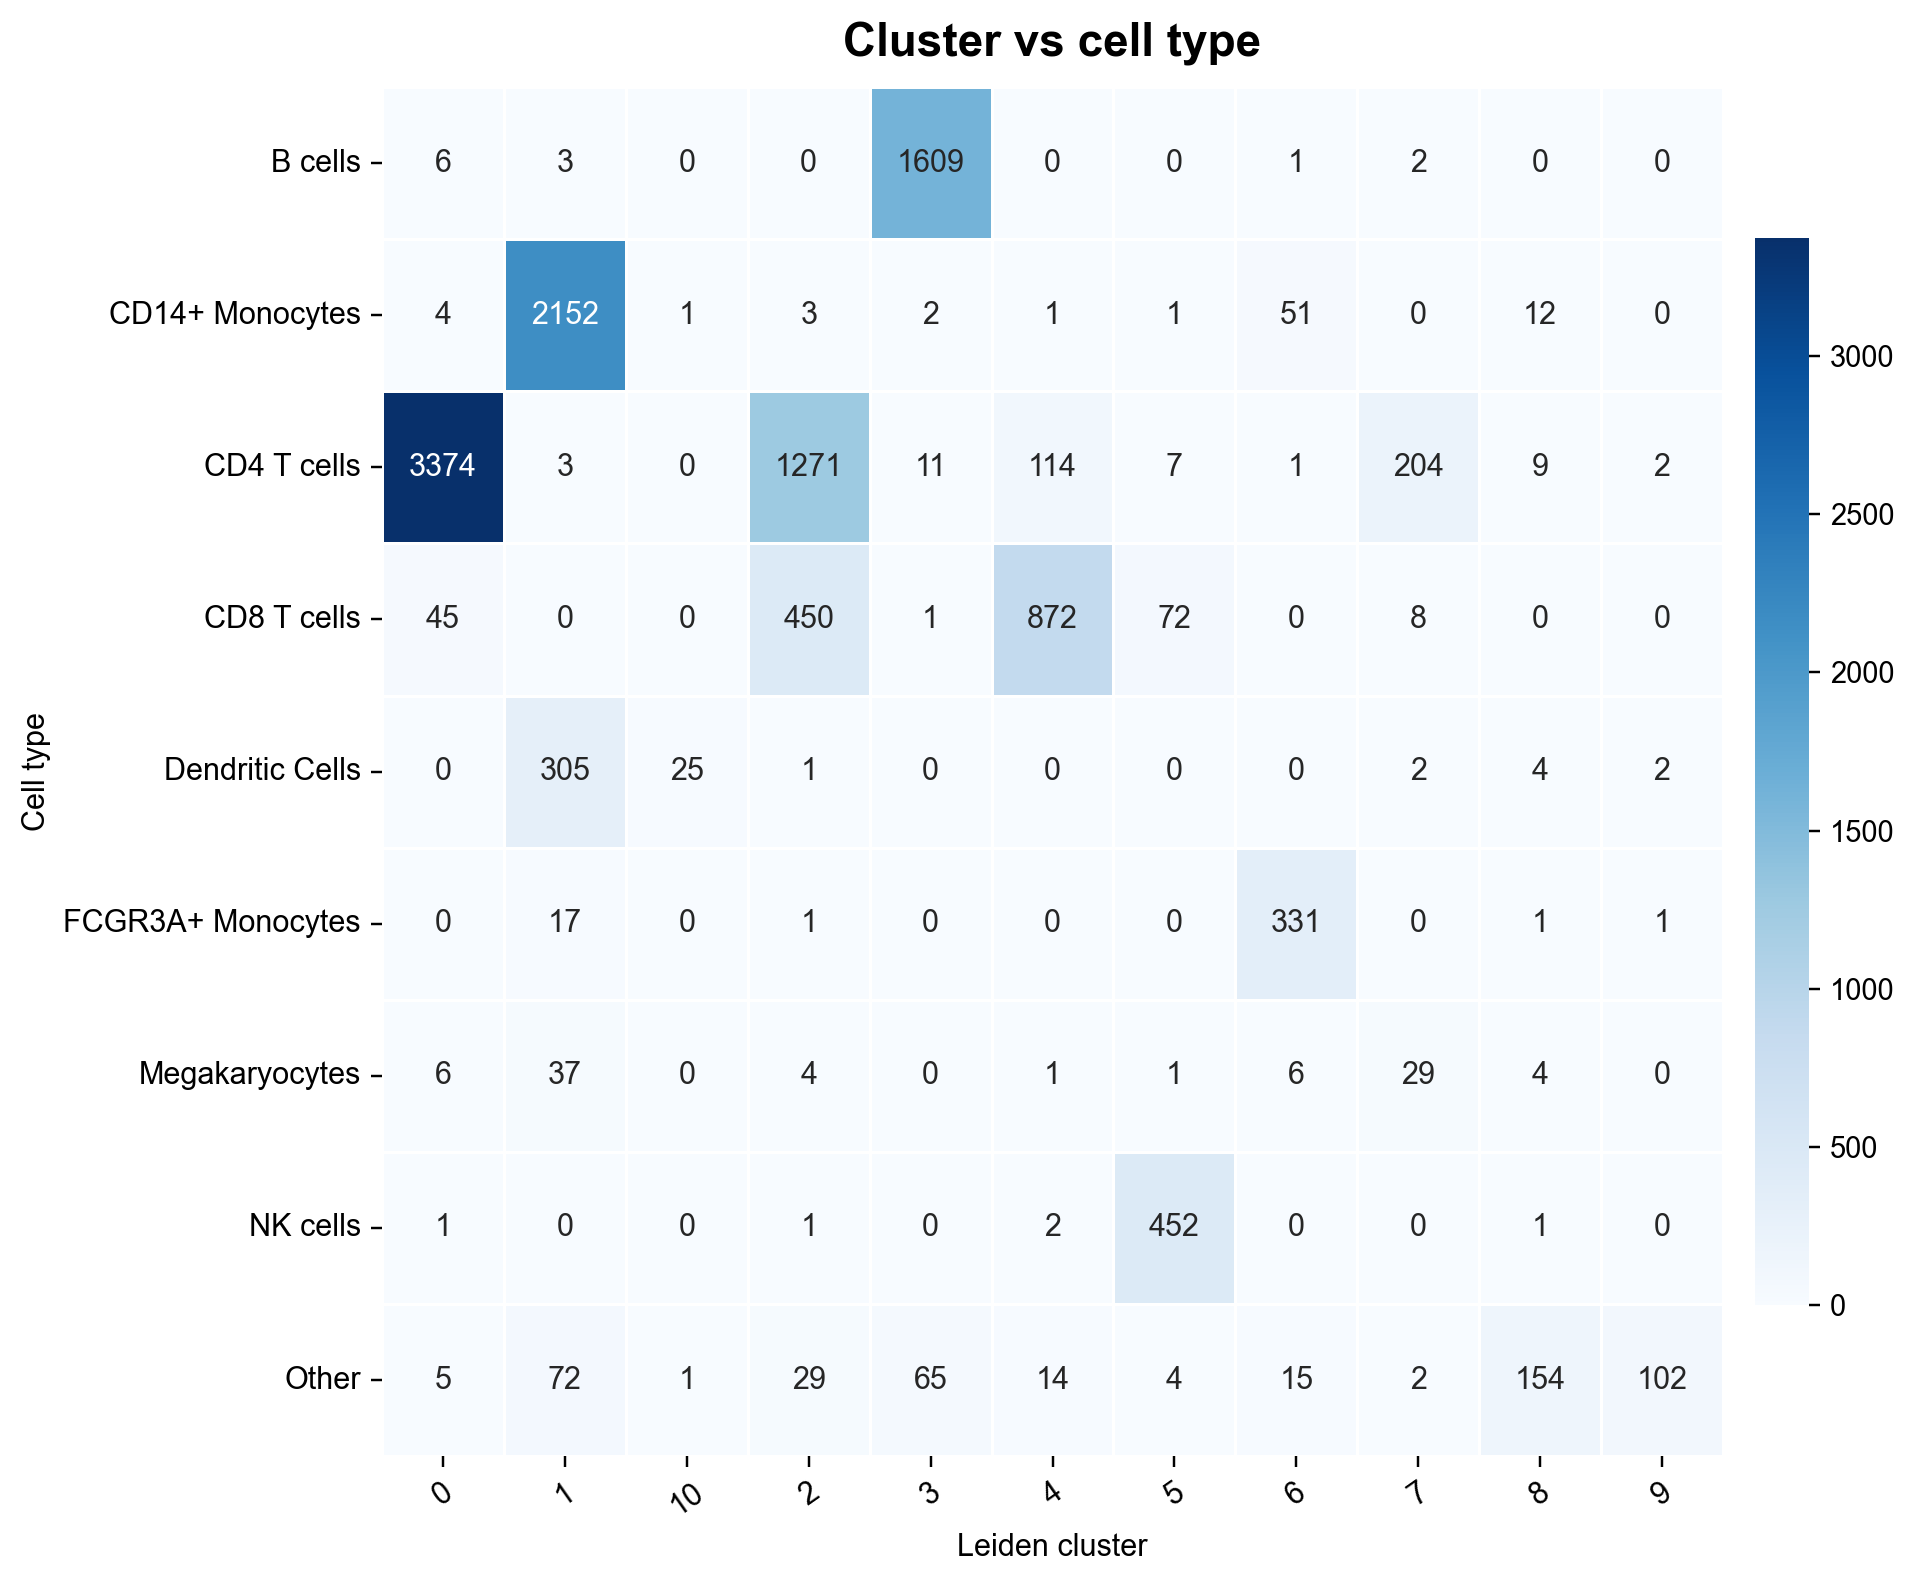

E:\CODE\trishift\artifacts\paper_figures\supp\FigS6_Stage1LatentClustering\figs6d_cluster_metrics.png


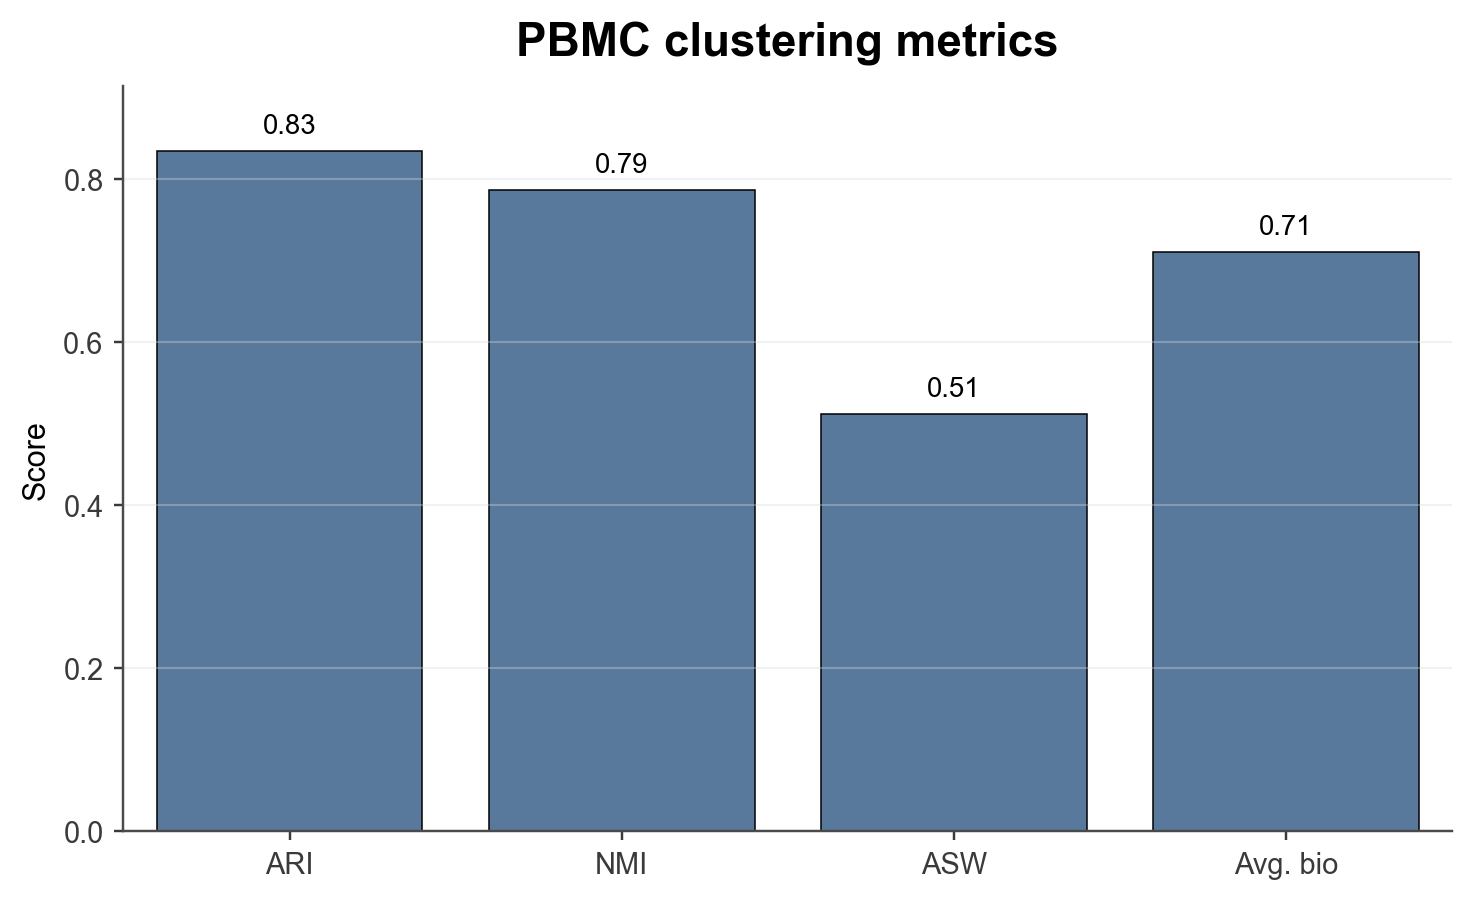

E:\CODE\trishift\artifacts\paper_figures\supp\FigS6_Stage1LatentClustering


In [5]:
for image_name in [
    'figs6a_umap_by_cluster.png',
    'figs6b_umap_by_cell_type.png',
    'figs6c_cluster_vs_cell_type.png',
    'figs6d_cluster_metrics.png',
]:
    image_path = OUT_ROOT / image_name
    print(image_path)
    if image_path.exists():
        display(Image(filename=str(image_path), width=900))
print(OUT_ROOT)
